In [1]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np



In [2]:
sentences = [
   # Cricket (4)
   "Virat Kohli scored a century in the match",
   "The bowler took three wickets in one over",
   "Cricket is very popular in India",
   "The team won the match by five runs",

   # Cooking (3)
   "I cooked pasta with tomato sauce",
   "Frying vegetables improves taste",
   "Baking requires precise temperature control",

   # Cybersecurity (3)
   "Strong passwords protect your accounts",
   "Hackers try to exploit system vulnerabilities",
   "Cybersecurity helps prevent data breaches"
]

In [3]:
model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(sentences)

model.safetensors:   0%|          | 0.00/90.9M [00:00<?, ?B/s]

c:\Python\Python311\Lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Director\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

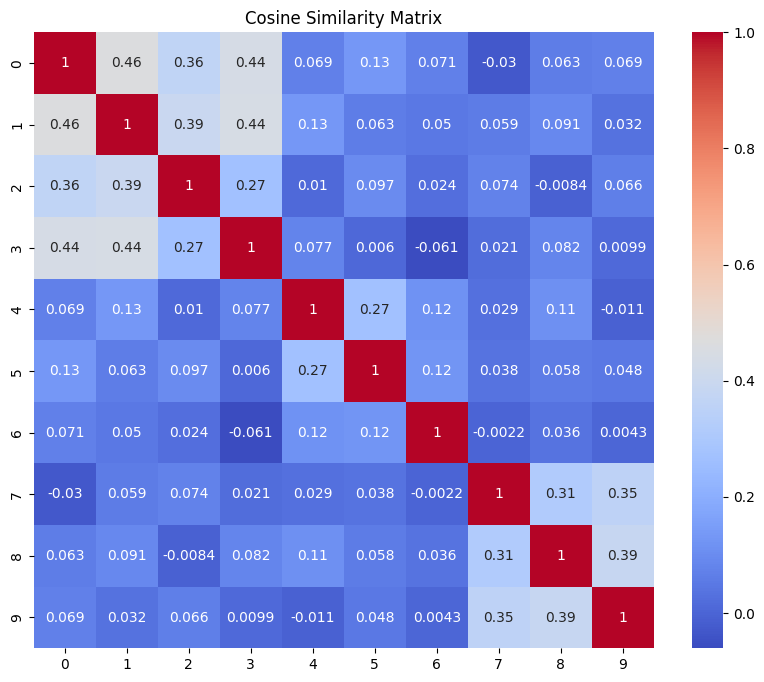

In [4]:
similarity_matrix = cosine_similarity(embeddings)

plt.figure(figsize=(10,8))
sns.heatmap(similarity_matrix, annot=True, cmap='coolwarm')
plt.title("Cosine Similarity Matrix")
plt.show()

In [5]:
query = "The bowler took three wickets in one over"

query_embedding = model.encode([query])
scores = cosine_similarity(query_embedding, embeddings)[0]

top_indices = np.argsort(scores)[-2:][::-1]

print("Top 2 similar sentences:\n")

for i in top_indices:
   print("Sentence:", sentences[i])
   print("Similarity Score:", round(scores[i], 4))
   print()

Top 2 similar sentences:

Sentence: The bowler took three wickets in one over
Similarity Score: 1.0

Sentence: Virat Kohli scored a century in the match
Similarity Score: 0.4623

